<a href="https://colab.research.google.com/github/jiissung/ECON3916-Statistical-Machine-Learning/blob/main/Class%2010/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

# Define time horizon
start = "2010-01-01"
end = "2024-01-01"

# Fetch a focused set of macro indicators
series = {
    "CPIAUCSL": "cpi",      # Consumer Price Index
    "UNRATE": "unrate",     # Unemployment Rate
    "FEDFUNDS": "fedfunds", # Fed Funds Rate
    "INDPRO": "indpro",     # Industrial Production
    "M2SL": "m2"            # M2 Money Supply
}

# Pull data, normalize to monthly start, and drop NAs
df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


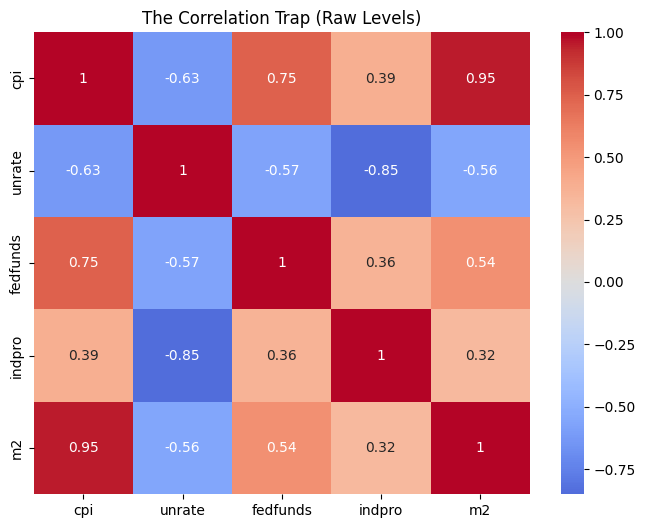

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

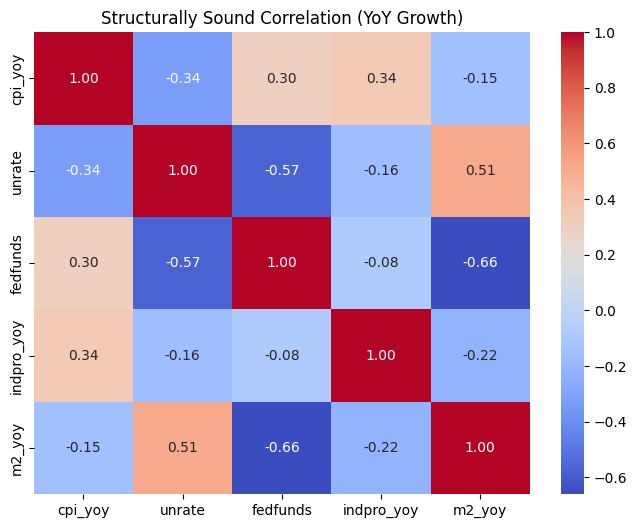

In [4]:
# Step 4

df_t = df.copy()

for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

df_t = df_t.dropna()

cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

M2 and CPI are not directly casual. They are both descendants of a common unboserved confounder (Exapnsionary Macro Policy). Both variables are influenced by upstream policy as seen on the chart. The correlation between federal funds and M2  YoY is = -0.66 (Strong Relationship). CPI and M2 have a correlation of -0.15 (Weak Relationship).


Exapnsionary Macro Policy -> FedFunds & M2

In [7]:
# 3
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# -----------------------------
# 1. Create YoY Transformations
# -----------------------------
# Percent change over 12 months
df_yoy = df.pct_change(12) * 100

# Rename columns so they are distinguishable
df_yoy.columns = [col + "_yoy" for col in df_yoy.columns]

# Drop NA values created by transformation
df_yoy = df_yoy.dropna()

# Align datasets
df_raw = df.loc[df_yoy.index]

# -----------------------------
# 2. Compute Correlation Matrices
# -----------------------------
corr_raw = df_raw.corr()
corr_yoy = df_yoy.corr()

# -----------------------------
# 3. Create Heatmap Figure
# -----------------------------
fig = go.Figure()

# Raw correlation heatmap
fig.add_trace(
    go.Heatmap(
        z=corr_raw.values,
        x=corr_raw.columns,
        y=corr_raw.columns,
        colorscale="RdBu",
        zmin=-1,
        zmax=1,
        text=np.round(corr_raw.values, 2),
        texttemplate="%{text}",
        textfont={"size":12},
        visible=True,
        colorbar=dict(title="Correlation")
    )
)

# YoY correlation heatmap
fig.add_trace(
    go.Heatmap(
        z=corr_yoy.values,
        x=corr_yoy.columns,
        y=corr_yoy.columns,
        colorscale="RdBu",
        zmin=-1,
        zmax=1,
        text=np.round(corr_yoy.values, 2),
        texttemplate="%{text}",
        textfont={"size":12},
        visible=False
    )
)

# -----------------------------
# 4. Add Dropdown Menu
# -----------------------------
fig.update_layout(
    title="Macroeconomic Correlation Dashboard",
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            buttons=list([
                dict(
                    label="Raw Levels",
                    method="update",
                    args=[
                        {"visible": [True, False]},
                        {"title": "Correlation Matrix — Raw Levels"}
                    ]
                ),
                dict(
                    label="YoY Growth Rates",
                    method="update",
                    args=[
                        {"visible": [False, True]},
                        {"title": "Correlation Matrix — YoY Transformed"}
                    ]
                )
            ]),
            x=1.05,
            y=1
        )
    ]
)

fig.update_layout(
    width=700,
    height=600
)

fig.show()